# L8 / L12 / L16 DiT: PCA generalization at a 95th-percentile threshold

This notebook computes the curve from **saved generated arrays and each run's exact training subset**, not from previously printed pixel-cosine summaries. No training, sampling, probe inference, or downloads.

**Definition:** fit one shared, pixel-standardized 32-component PCA basis on up to 1,024 real maps from the largest verified L16 run, shared across all three depths. For each N, compute every real map's nearest *other* training map in PCA cosine space. Set the copying threshold to the **95th percentile of those real–real maxima**. A generated map is a near-copy when its maximum cosine to all N training maps is ≥ that threshold. Generalization score = 1 − near-copy fraction.

This is a novelty diagnostic, **not a guarantee of physical fidelity**. The threshold is N-dependent. “95%” here is a calibration percentile, not 95% explained variance or cosine 0.95. The older PCA notebook used the same percentile approach with q=0.99; this notebook explicitly uses q=0.95. A fixed-cosine alternative is configurable below.

Run on an allocated CPU node with NumPy, SciPy, scikit-learn, pandas, matplotlib and the repository available. The full-reference real–real search can take minutes. No jobs are submitted by this notebook. Missing sizes remain missing, including L16 N=256 unless a comparable saved run is present.


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display

PROJECT_DIR = Path("/home/jiamingp/diffusion_models_repo")
if not PROJECT_DIR.is_dir():
    PROJECT_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / "simdiff_eval").is_dir()), None)
if PROJECT_DIR is None:
    raise RuntimeError("Set PROJECT_DIR to the repository.")
sys.path.insert(0, str(PROJECT_DIR))
from simdiff_eval.io import iter_real_reference_batches_from_config

BASE = Path("/scratch/huterer_root/huterer0/jiamingp")
PLAN_PATHS = [
    BASE / "dit_l16_adalnzero_highn_screen_v1/plan.json",
    BASE / "dit_zero_remaining_300k_v1/plan.json",
]
SEED = 123
SAMPLE_LABEL = "dpm50_n512"
PCA_COMPONENTS = 32
PCA_MAX_FIT_REAL = 1024
THRESHOLD_MODE = "real_nn_quantile"  # alternative: "fixed_cosine"
COPY_QUANTILE = 0.95
FIXED_COSINE = 0.95
BLOCK_SIZE = 256
SAVE_OUTPUTS = False
OUTPUT_DIR = PROJECT_DIR / "notebooks/executed/dit_depths_pca95"


## 1. Verify saved inputs
Only complete, hash-matched L8/L12/L16 patch-8 sample files are admitted. Invalid provenance stops execution rather than silently changing the curve.


In [2]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

runs, inventory = [], []
for plan_path in PLAN_PATHS:
    if not plan_path.is_file():
        raise FileNotFoundError(plan_path)
    plan_hash = sha256(plan_path)
    for row in json.loads(plan_path.read_text())["runs"]:
        if int(row["num_layers"]) not in (8, 12, 16) or int(row["patch_size"]) != 8:
            continue
        sample = Path(row["sample_path"].format(seed=SEED, sample_label=SAMPLE_LABEL))
        receipt = sample.with_suffix(".complete.json")
        item = dict(depth=int(row["num_layers"]), N=int(row["dataset_size"]), run_name=row["run_name"],
                    config=str(row["config"]), sample=str(sample), plan=str(plan_path),
                    plan_sha256=plan_hash)
        if not sample.is_file() or not receipt.is_file():
            inventory.append(dict(**item, status="missing sample or receipt"))
            continue
        saved = json.loads(receipt.read_text())
        assert saved["status"] == "complete", receipt
        assert saved["plan_sha256"] == plan_hash, receipt
        sample_hash = sha256(sample)
        assert saved["samples_sha256"] == sample_hash, sample
        config_hash = sha256(row["config"])
        if row.get("config_sha256"):
            assert row["config_sha256"] == config_hash, row["config"]
        item.update(samples_sha256=sample_hash, config_sha256=config_hash)
        runs.append(item)
        inventory.append(dict(**item, status="verified"))
display(pd.DataFrame(inventory)[["depth", "N", "run_name", "status", "sample"]].sort_values(["depth", "N"]))
runs.sort(key=lambda r: (r["depth"], r["N"]))
assert runs, "No verified samples available."
assert len({(r["depth"], r["N"]) for r in runs}) == len(runs), "Duplicate depth/N: explicitly select comparable runs."
for depth in (8,12,16):
    print(f"L{depth} missing sizes:", sorted(set(2**k for k in range(6,16)) -
          {r["N"] for r in runs if r["depth"]==depth}))


,depth,N,run_name,status,sample
19,8,64,nf_fig2_dit_l8_d2p06_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
20,8,128,nf_fig2_dit_l8_d2p07_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
21,8,256,nf_fig2_dit_l8_d2p08_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
22,8,512,nf_fig2_dit_l8_d2p09_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
23,8,1024,nf_fig2_dit_l8_d2p10_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
24,8,2048,nf_fig2_dit_l8_d2p11_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
25,8,4096,nf_fig2_dit_l8_d2p12_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
26,8,8192,nf_fig2_dit_l8_d2p13_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
27,8,16384,nf_fig2_dit_l8_d2p14_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...
28,8,32768,nf_fig2_dit_l8_d2p15_p8_adalnzero_fresh_300000...,verified,/gpfs/accounts/huterer_root/huterer0/jiamingp/...


L8 missing sizes: []
L12 missing sizes: []
L16 missing sizes: [256]


## 2. One shared PCA basis
The basis uses only real maps. All exact training maps—not a capped reference subset—are subsequently searched. The fit subset alone is capped to bound the PCA fitting cost.


In [3]:
def flat(images):
    a = np.asarray(images, dtype=np.float32)
    assert a.ndim == 4 and a.shape[1:] == (1, 128, 128), a.shape
    assert np.isfinite(a).all()
    return a.reshape(len(a), -1)

largest = max((r for r in runs if r["depth"] == 16), key=lambda r: r["N"])
fit_indices = np.linspace(0, largest["N"] - 1,
                          min(PCA_MAX_FIT_REAL, largest["N"]), dtype=int)
parts, offset = [], 0
for batch in iter_real_reference_batches_from_config(largest["config"]):
    selected = fit_indices[(fit_indices >= offset) & (fit_indices < offset + len(batch))]
    if len(selected):
        parts.append(flat(batch[selected - offset]))
    offset += len(batch)
assert offset == largest["N"], (offset, largest["N"])
fit_x = np.concatenate(parts)
mean = fit_x.mean(axis=0)
scale = fit_x.std(axis=0)
scale[scale < 1e-6] = 1.0
pca = PCA(n_components=min(PCA_COMPONENTS, len(fit_x)-1),
          svd_solver="randomized", random_state=0)
pca.fit((fit_x - mean) / scale)
print("Fit source:", largest["run_name"])
print("Fit maps:", len(fit_x), "Components:", pca.n_components_)
print("Explained variance fraction:", float(pca.explained_variance_ratio_.sum()))
del fit_x, parts

def project(images):
    z = pca.transform((flat(images) - mean) / scale).astype(np.float32)
    norms = np.linalg.norm(z, axis=1, keepdims=True)
    if np.any(norms <= 1e-12):
        raise ValueError("Zero-norm PCA embedding: cosine is undefined.")
    return z / norms

def nearest_cosine(query, reference, exclude_self=False):
    if exclude_self:
        assert query is reference and len(reference) > 1
    answer = np.empty(len(query), dtype=np.float32)
    for start in range(0, len(query), BLOCK_SIZE):
        scores = query[start:start+BLOCK_SIZE] @ reference.T
        if exclude_self:
            idx = np.arange(len(scores))
            scores[idx, start+idx] = -np.inf
        answer[start:start+len(scores)] = scores.max(axis=1)
    return np.clip(answer, -1, 1)


Fit source: nf_fig2_dit_l16_d2p15_p8_adalnzero_fresh_300000u_seed123
Fit maps: 1024 Components: 32
Explained variance fraction: 0.3356020450592041


## 3. Compute the curve
Each generated image gets its own maximum over **all N training maps**; the plotted score aggregates all generated images. Real–real calibration excludes each map's self-match.


In [4]:
results, per_sample = [], {}
for run in runs:
    print("Computing depth, N =", run["depth"], run["N"], flush=True)
    real_z = np.concatenate([project(b) for b in
                            iter_real_reference_batches_from_config(run["config"])])
    assert len(real_z) == run["N"], (len(real_z), run["N"])
    with np.load(run["sample"], allow_pickle=False) as saved:
        generated = np.asarray(saved["samples"], dtype=np.float32)
    assert generated.shape == (512, 1, 128, 128), generated.shape
    generated_z = project(generated)
    real_nn = nearest_cosine(real_z, real_z, exclude_self=True)
    generated_nn = nearest_cosine(generated_z, real_z)
    if THRESHOLD_MODE == "real_nn_quantile":
        threshold = float(np.quantile(real_nn, COPY_QUANTILE))
    elif THRESHOLD_MODE == "fixed_cosine":
        threshold = FIXED_COSINE
    else:
        raise ValueError(THRESHOLD_MODE)
    copying = generated_nn >= threshold
    results.append(dict(depth=run["depth"], N=run["N"], n_generated=len(copying),
                        threshold=threshold, copy_fraction=float(copying.mean()),
                        generalization=float((~copying).mean()),
                        generated_median=float(np.median(generated_nn)),
                        real_nn_median=float(np.median(real_nn))))
    per_sample["L%d_N%d" % (run["depth"], run["N"])] = dict(real_nn=real_nn, generated_nn=generated_nn)
    del real_z, generated, generated_z
summary = pd.DataFrame(results).sort_values(["depth","N"])
display(summary)


Computing depth, N = 8 64
Computing depth, N = 8 128
Computing depth, N = 8 256
Computing depth, N = 8 512
Computing depth, N = 8 1024
Computing depth, N = 8 2048
Computing depth, N = 8 4096
Computing depth, N = 8 8192
Computing depth, N = 8 16384
Computing depth, N = 8 32768
Computing depth, N = 12 64
Computing depth, N = 12 128
Computing depth, N = 12 256
Computing depth, N = 12 512
Computing depth, N = 12 1024
Computing depth, N = 12 2048
Computing depth, N = 12 4096
Computing depth, N = 12 8192
Computing depth, N = 12 16384
Computing depth, N = 12 32768
Computing depth, N = 16 64
Computing depth, N = 16 128
Computing depth, N = 16 512
Computing depth, N = 16 1024
Computing depth, N = 16 2048
Computing depth, N = 16 4096
Computing depth, N = 16 8192
Computing depth, N = 16 16384
Computing depth, N = 16 32768


,depth,N,n_generated,threshold,copy_fraction,generalization,generated_median,real_nn_median
0,8,64,512,0.916614,1.000000,0.000000,0.999978,0.866715
1,8,128,512,0.994021,1.000000,0.000000,0.999958,0.962078
2,8,256,512,0.997605,0.974609,0.025391,0.999889,0.983369
3,8,512,512,0.996545,0.783203,0.216797,0.999263,0.958387
4,8,1024,512,0.998002,0.265625,0.734375,0.994199,0.968633
5,8,2048,512,0.997371,0.000000,1.000000,0.943869,0.958988
6,8,4096,512,0.996387,0.000000,1.000000,0.842722,0.927834
7,8,8192,512,0.992582,0.000000,1.000000,0.830150,0.901831
8,8,16384,512,0.981387,0.000000,1.000000,0.801256,0.889862
9,8,32768,512,0.969174,0.000000,1.000000,0.839633,0.885365


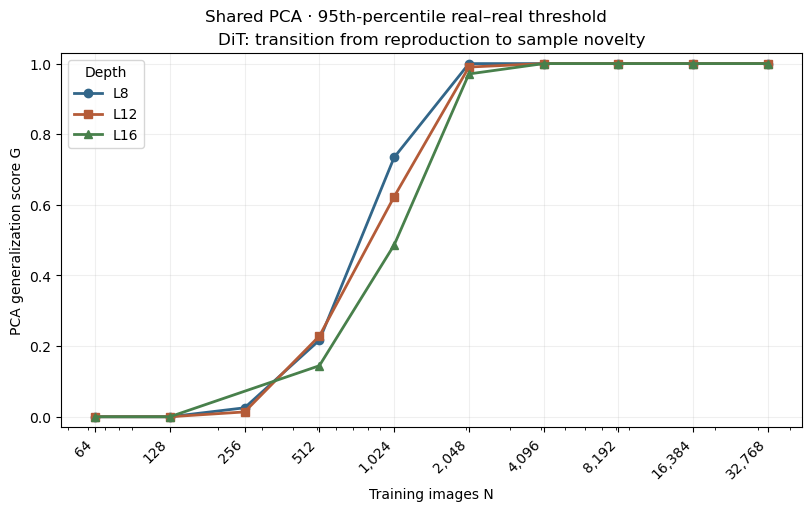

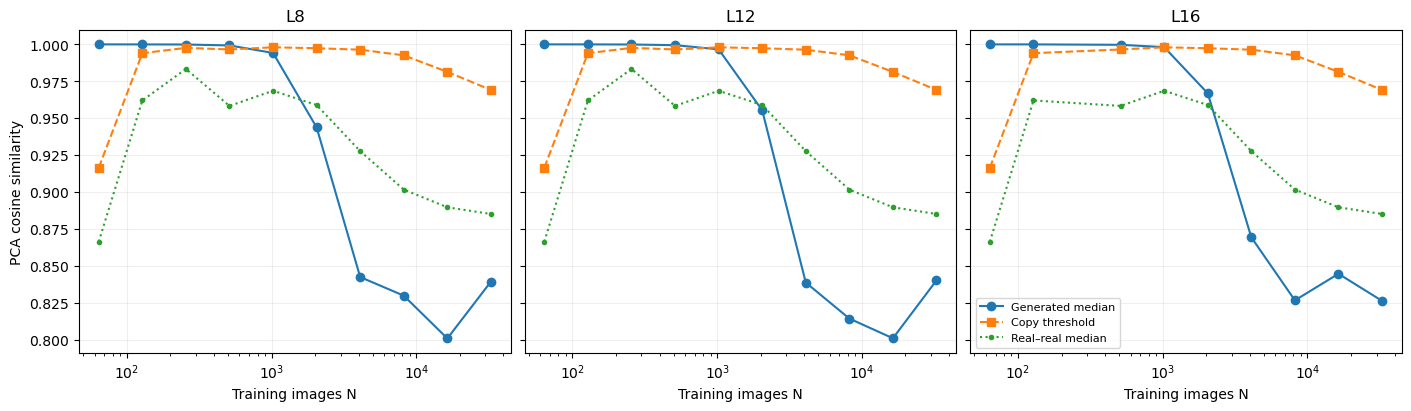

In [5]:
assert THRESHOLD_MODE == "real_nn_quantile" and COPY_QUANTILE == 0.95
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
styles = {8:("#326689","o"),12:("#b45b38","s"),16:("#48804b","^")}
for depth,(color,marker) in styles.items():
    sub=summary[summary.depth==depth].sort_values("N")
    ax.plot(sub.N,sub.generalization,color=color,marker=marker,lw=2,label=f"L{depth}")
ax.set(xscale="log",ylim=(-.03,1.03),xlabel="Training images N",
       ylabel="PCA generalization score G",title="DiT: transition from reproduction to sample novelty")
ticks=sorted(summary.N.unique())
ax.set_xticks(ticks)
ax.set_xticklabels([f"{n:,}" for n in ticks],rotation=45,ha="right")
ax.grid(alpha=.2)
ax.legend(title="Depth")
fig.suptitle("Shared PCA · 95th-percentile real–real threshold")
plt.show()

diagnostic_fig,axes=plt.subplots(1,3,figsize=(14,4),sharey=True,constrained_layout=True)
for ax,depth in zip(axes,(8,12,16)):
    sub=summary[summary.depth==depth].sort_values("N")
    ax.plot(sub.N,sub.generated_median,"o-",label="Generated median")
    ax.plot(sub.N,sub.threshold,"s--",label="Copy threshold")
    ax.plot(sub.N,sub.real_nn_median,".:",label="Real–real median")
    ax.set(xscale="log",xlabel="Training images N",title=f"L{depth}")
    ax.grid(alpha=.2)
axes[0].set_ylabel("PCA cosine similarity")
axes[-1].legend(fontsize=8)
plt.show()


## Interpretation and optional export

A score near zero means almost all generated maps exceed the calibrated copying threshold; a score near one means almost none do. It does **not** show that the power spectrum, morphology, or cosmology recovery is correct. Compare the existing power diagnostics separately. Connecting available sizes is a visual guide, not an estimate for missing sizes.

The exported provenance records the shared PCA fit source and every admitted input. No files are written unless SAVE_OUTPUTS is enabled. Preserve previous executed notebooks by saving this notebook under a new executed filename.


In [6]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    targets = [OUTPUT_DIR / name for name in
               ["summary.csv", "provenance.json", "pca_generalization.png", "similarities.npz"]]
    if any(p.exists() for p in targets):
        raise FileExistsError("Choose a fresh OUTPUT_DIR; previous outputs will not be overwritten.")
    summary.to_csv(targets[0], index=False)
    provenance = dict(runs=runs, fit_run=largest, fit_indices=fit_indices.tolist(),
                      components=int(pca.n_components_), threshold_mode=THRESHOLD_MODE,
                      quantile=COPY_QUANTILE, fixed_cosine=FIXED_COSINE,
                      explained_variance=pca.explained_variance_ratio_.tolist())
    targets[1].write_text(json.dumps(provenance, indent=2))
    fig.savefig(targets[2], dpi=180, bbox_inches="tight")
    np.savez_compressed(targets[3], **{
        f"{n}_{key}": value for n, arrays in per_sample.items()
        for key, value in arrays.items()})
    print("Saved:", OUTPUT_DIR)
